# Task
Perform a comprehensive analysis of the Netflix dataset from `/content/netflix_titles.csv`. This involves loading the dataset, inspecting its structure, cleaning missing values, standardizing data, and converting data types. Analyze content by rating, country, type (Movies vs. TV Shows), and release year. Explore yearly trends in title additions. Visualize content type distribution, top countries, yearly title additions, and the relationship between release year and duration for movies. Generate a correlation heatmap for relevant numerical features. Finally, summarize all findings and provide an actionable recommendation for Netflix's content strategy.

## Load Dataset and Initial Inspection

### Subtask:
Load the Netflix dataset from the local file /content/netflix_titles.csv into a pandas DataFrame. Inspect the first 10 entries to understand its structure. Print the DataFrame's shape (number of rows and columns), all column names, their respective data types, and report the total count of missing values for each column.


**Reasoning**:
To address the subtask, I will import the pandas library, load the dataset from the specified CSV file into a DataFrame, display the first 10 rows, print the DataFrame's shape, show column names and their data types, and report the total count of missing values for each column.



In [23]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles.csv')

print("First 10 rows of the DataFrame:")
print(df.head(10))

print("\nShape of the DataFrame:")
print(df.shape)

print("\nDataFrame Info (Column Names and Data Types):")
df.info()

print("\nTotal count of missing values for each column:")
print(df.isnull().sum())

First 10 rows of the DataFrame:
  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans   
4      s5  TV Show                      Kota Factory   
5      s6  TV Show                     Midnight Mass   
6      s7    Movie  My Little Pony: A New Generation   
7      s8    Movie                           Sankofa   
8      s9  TV Show     The Great British Baking Show   
9     s10    Movie                      The Starling   

                        director  \
0                Kirsten Johnson   
1                            NaN   
2                Julien Leclercq   
3                            NaN   
4                            NaN   
5                  Mike Flanagan   
6  Robert Cullen, José Luis Ucha   
7                   Haile Gerima   
8                Andy Devon

## Clean Data

### Subtask:
Handle missing values in the dataset using appropriate methods (e.g., fill 'director', 'cast', 'country' with 'Unknown', 'rating' with mode, or drop rows/columns if necessary after assessment). Standardize casing for string columns like 'type' and 'rating'. Convert the 'date_added' column to datetime objects for easier time-series analysis. For the 'duration' column, extract the numeric value for movies (e.g., 'X min') and handle TV show durations (e.g., 'X Seasons') appropriately, possibly converting them to a common numeric scale or analyzing separately if needed for visualizations.


**Reasoning**:
The subtask requires several data cleaning operations: handling missing values, standardizing casing, converting data types, and extracting numerical duration information. I will perform these operations sequentially in a single code block to clean the dataframe as per the instructions.



In [25]:
import numpy as np

# 1. Fill missing values in 'director', 'cast', and 'country' with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# 2. Fill missing values in 'rating' with the most frequent rating (mode)
mode_rating = df['rating'].mode()[0]
df['rating'].fillna(mode_rating, inplace=True)

# 3. Drop rows where 'date_added' has missing values
df.dropna(subset=['date_added'], inplace=True)

# 4. Drop rows where 'duration' has missing values
df.dropna(subset=['duration'], inplace=True)

# 5. Convert 'type' and 'rating' columns to lowercase
df['type'] = df['type'].str.lower()
df['rating'] = df['rating'].str.lower()

# 6. Convert the 'date_added' column to datetime objects, handling mixed formats
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# 7. Create 'duration_min' for movies and 'duration_seasons' for TV shows
df['duration_min'] = np.nan
df['duration_seasons'] = np.nan

# Extract numeric duration for movies
movies_df = df[df['type'] == 'movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.extract(r'(\d+)').astype(int)
df.update(movies_df)

# Extract numeric duration for TV shows
tvshows_df = df[df['type'] == 'tv show'].copy()
tvshows_df['duration_seasons'] = tvshows_df['duration'].str.extract(r'(\d+)').astype(int)
df.update(tvshows_df)

# 8. Verify the data cleaning
print("\nTotal count of missing values after cleaning:")
print(df.isnull().sum())

print("\nDataFrame Info after cleaning (Column Names and Data Types):")
df.info()

/tmp/ipython-input-2653394070.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipython-input-2653394070.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin


Total count of missing values after cleaning:
show_id                0
type                   0
title                  0
director               0
cast                   0
country                0
date_added             0
release_year           0
rating                 0
duration               0
listed_in              0
description            0
duration_min        2666
duration_seasons    6128
dtype: int64

DataFrame Info after cleaning (Column Names and Data Types):
<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8794 non-null   object        
 1   type              8794 non-null   object        
 2   title             8794 non-null   object        
 3   director          8794 non-null   object        
 4   cast              8794 non-null   object        
 5   country           8794 non-null   object   

**Reasoning**:
The data cleaning and preprocessing steps are complete, including handling missing values, standardizing casing, converting data types, and extracting duration information. The next logical step, according to the overall task, is to analyze the content by type and explore yearly trends in title additions.



In [27]:
# Analyze Content and Trends

# 1. Calculate the percentage distribution of 'Movie' and 'TV Show' in the dataset.
content_type_distribution = df['type'].value_counts(normalize=True) * 100

# 2. Extract the 'year_added' from the 'date_added' column.
df['year_added'] = df['date_added'].dt.year

# 3. Count the number of titles added each year and store it in a new DataFrame or Series.
yearly_content_additions = df['year_added'].value_counts().sort_index()

# 4. Print the content type distribution and the yearly content addition counts.
print("\nContent Type Distribution (Percentage):")
print(content_type_distribution)

print("\nYearly Content Additions:")
print(yearly_content_additions)


Content Type Distribution (Percentage):
type
movie      69.683875
tv show    30.316125
Name: proportion, dtype: float64

Yearly Content Additions:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


**Reasoning**:
The previous step successfully calculated the content type distribution and yearly content additions. As per the main task, the next logical step is to visualize these findings. I will start by visualizing the distribution of content types (Movies vs. TV Shows) using a pie chart.



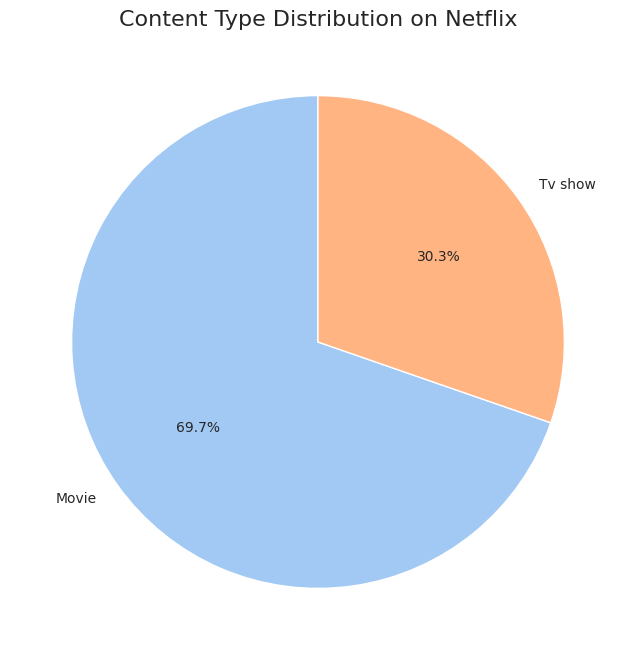

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
plt.figure(figsize=(8, 8))

# Plotting the content type distribution
plt.pie(content_type_distribution, labels=content_type_distribution.index.str.capitalize(),
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Content Type Distribution on Netflix', fontsize=16)
plt.ylabel('') # Hide the default 'y' label for pie chart
plt.show()

**Reasoning**:
The previous step successfully visualized the content type distribution. The next instruction in the subtask is to explore and visualize the yearly trends in content additions, which was calculated in a previous step.



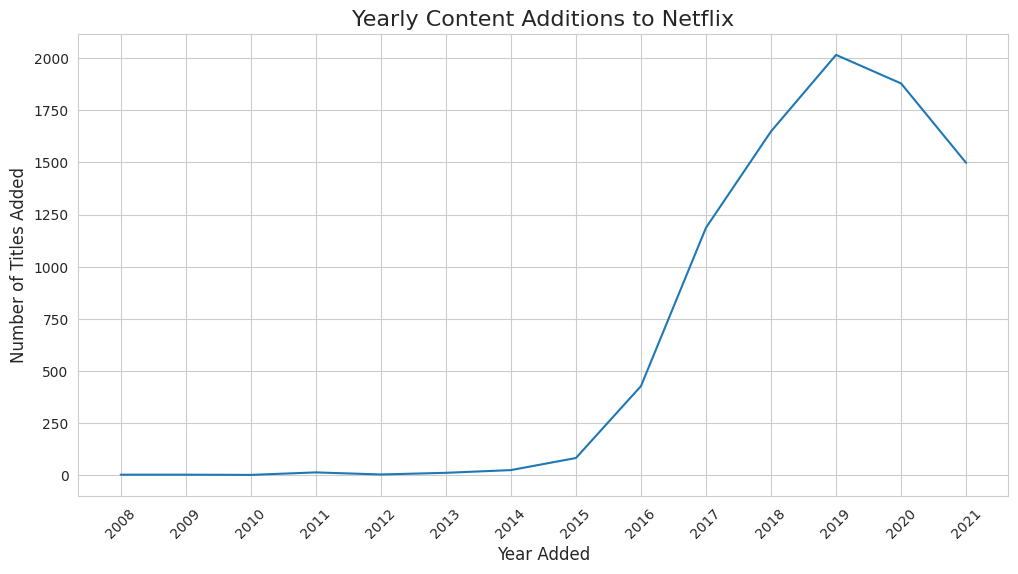

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_content_additions.index, y=yearly_content_additions.values)
plt.title('Yearly Content Additions to Netflix', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(yearly_content_additions.index, rotation=45)
plt.grid(True)
plt.show()

**Reasoning**:
The previous steps successfully calculated and visualized the content type distribution and yearly content additions. Following the overall task, the next logical step is to analyze content distribution by country. I will first process the 'country' column to handle multiple countries for a single title and then identify the top countries by content count.



In [30]:
import collections

# Split 'country' column where there are multiple countries listed for a single title
# Flatten the list of countries and count occurrences
country_count = collections.Counter()
for country_list in df['country'].str.split(', '):
    for country in country_list:
        country_count[country.strip()] += 1

# Convert to DataFrame for easier analysis and sorting
country_df = pd.DataFrame(country_count.items(), columns=['country', 'count'])
country_df = country_df.sort_values(by='count', ascending=False)

# Exclude 'Unknown' from top countries analysis for better insight
top_countries = country_df[country_df['country'] != 'Unknown'].head(10)

print("\nTop 10 Countries by Content Count (excluding 'Unknown'):")
print(top_countries)


Top 10 Countries by Content Count (excluding 'Unknown'):
           country  count
0    United States   3680
3            India   1046
6   United Kingdom    803
16          Canada    445
13          France    393
17           Japan    317
19           Spain    232
21     South Korea    231
7          Germany    226
10          Mexico    169


**Reasoning**:
The previous step successfully identified the top countries by content count. Now, I will visualize these top countries using a bar chart to provide a clear representation of content distribution by country.



/tmp/ipython-input-1520311839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='count', data=top_countries, palette='viridis')


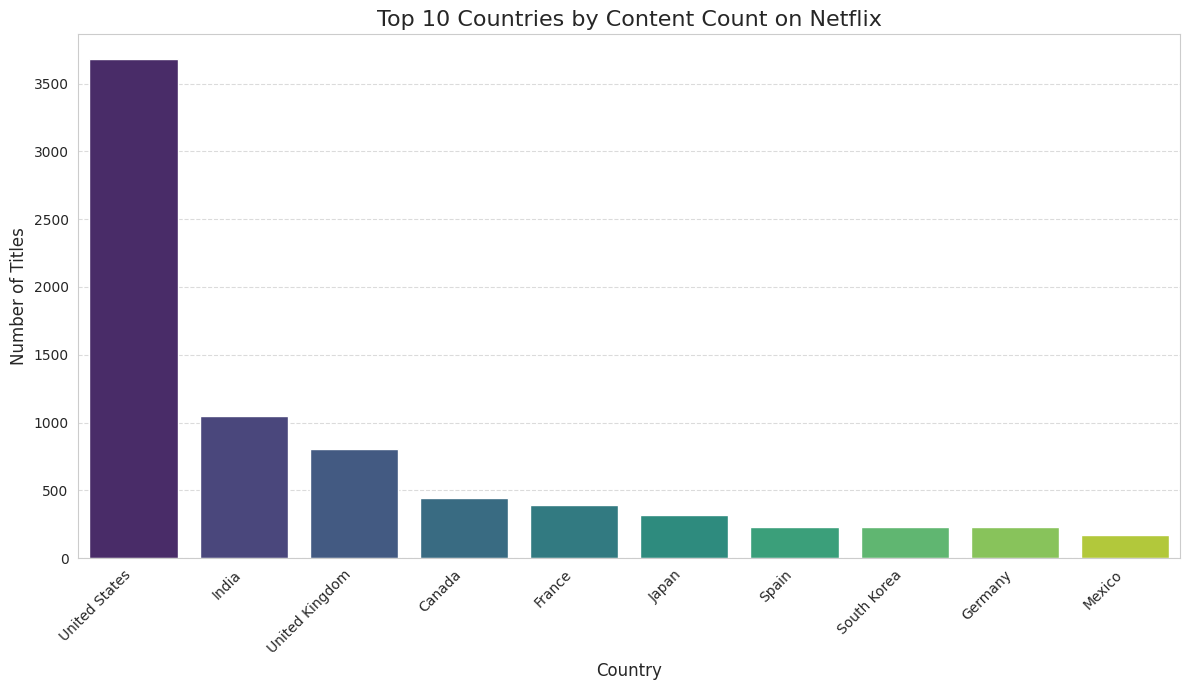

In [31]:
plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='count', data=top_countries, palette='viridis')
plt.title('Top 10 Countries by Content Count on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from seaborn because `palette` was used without explicitly setting the `hue` parameter. To address this and prevent future warnings, I will explicitly set `hue='country'` and `legend=False` in the `sns.barplot` function, as suggested by the warning.



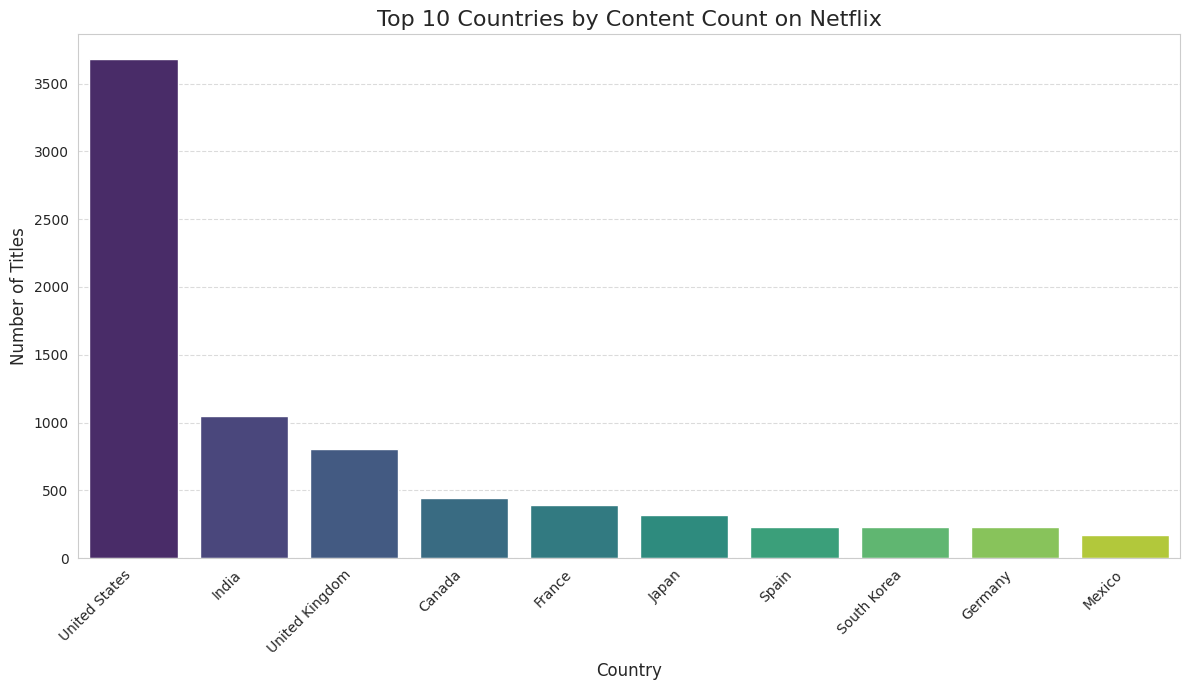

In [32]:
plt.figure(figsize=(12, 7))
sns.barplot(x='country', y='count', data=top_countries, palette='viridis', hue='country', legend=False)
plt.title('Top 10 Countries by Content Count on Netflix', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous steps successfully analyzed content type distribution, yearly additions, and top countries. Now, I will analyze the distribution of content by rating, which is another key aspect of the overall task. This involves counting the occurrences of each rating and then identifying the most frequent ones.



In [33]:
print("\nDistribution of Content Ratings:")
rating_distribution = df['rating'].value_counts()
print(rating_distribution.head(10)) # Print top 10 ratings for brevity


Distribution of Content Ratings:
rating
tv-ma    3209
tv-14    2157
tv-pg     861
r         799
pg-13     490
tv-y7     333
tv-y      306
pg        287
tv-g      220
nr         79
Name: count, dtype: int64


**Reasoning**:
The previous step successfully calculated the distribution of content ratings. The next logical step is to visualize this distribution using a bar chart to highlight the most common ratings.



/tmp/ipython-input-2951186518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_distribution.head(10).index, y=rating_distribution.head(10).values, palette='plasma')


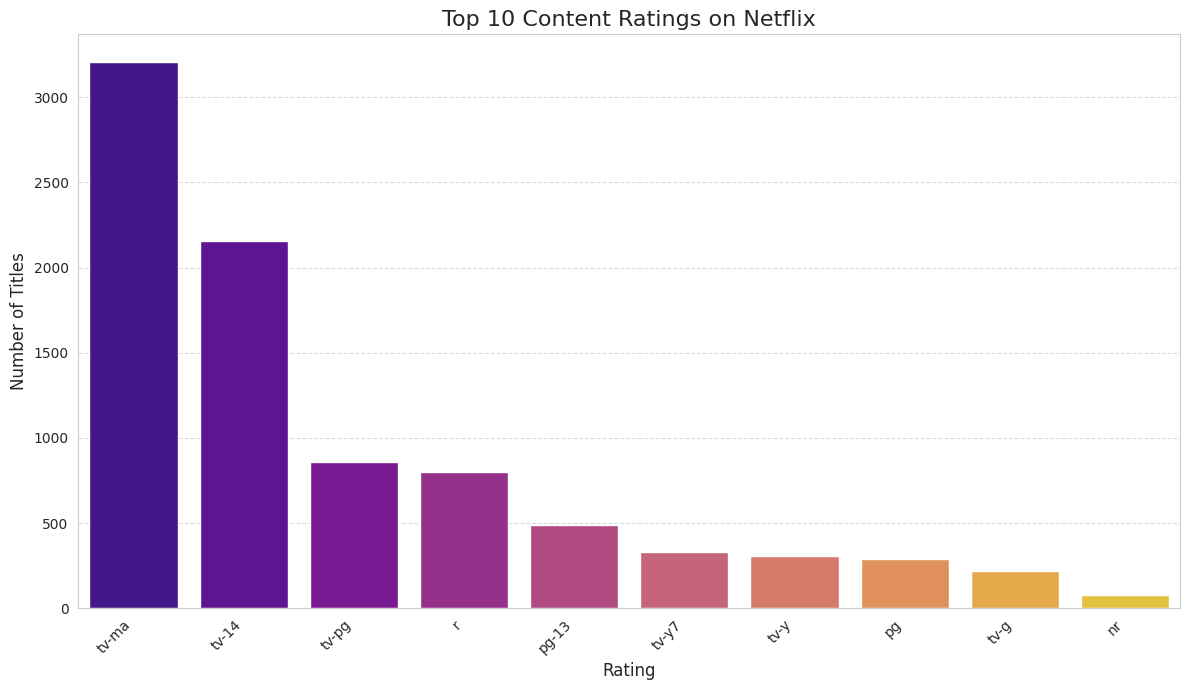

In [34]:
plt.figure(figsize=(12, 7))
sns.barplot(x=rating_distribution.head(10).index, y=rating_distribution.head(10).values, palette='plasma')
plt.title('Top 10 Content Ratings on Netflix', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from seaborn because `palette` was used without explicitly setting the `hue` parameter. To address this and prevent future warnings, I will explicitly set `hue` to the x-axis values and `legend=False` in the `sns.barplot` function, as suggested by the warning.



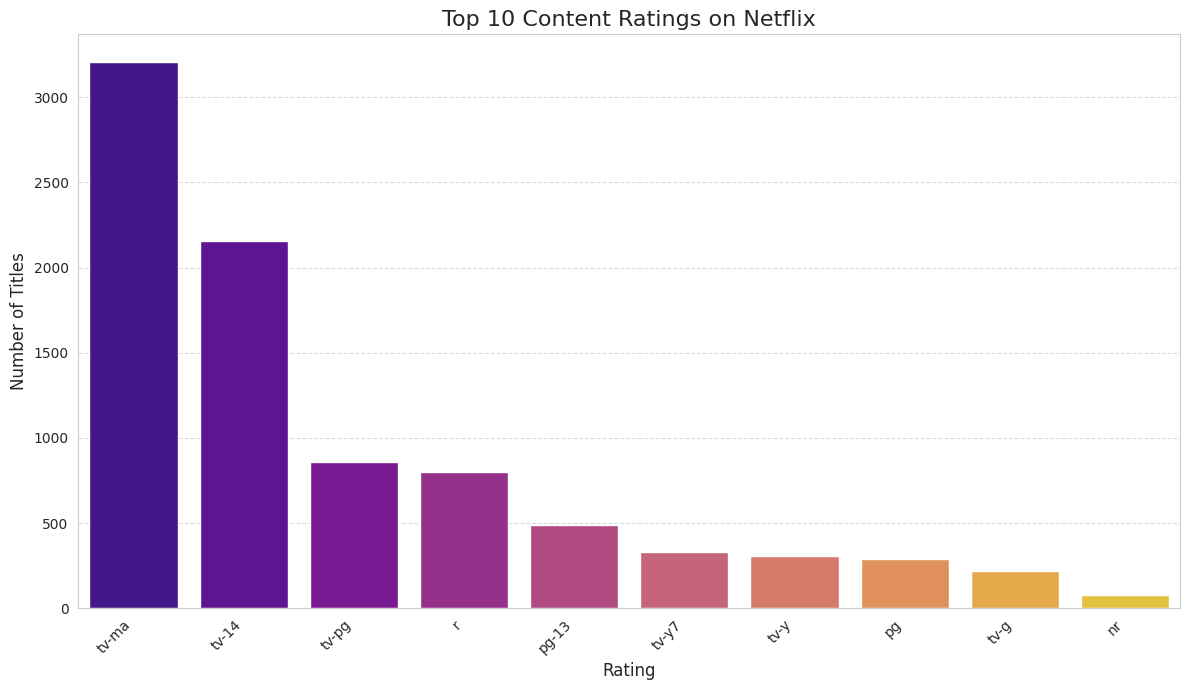

In [35]:
plt.figure(figsize=(12, 7))
sns.barplot(x=rating_distribution.head(10).index, y=rating_distribution.head(10).values, palette='plasma', hue=rating_distribution.head(10).index, legend=False)
plt.title('Top 10 Content Ratings on Netflix', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous steps successfully analyzed content type distribution, yearly additions, country distribution, and content ratings. The next logical step, as per the overall task, is to analyze the relationship between the release year and duration specifically for movies. I will prepare the data by filtering for movies and then visualize this relationship using a scatter plot.



First 5 rows of movies_only_df with release_year and duration_min:
    release_year  duration_min
0           2020            90
6           2021            91
7           1993           125
9           2021           104
12          2021           127


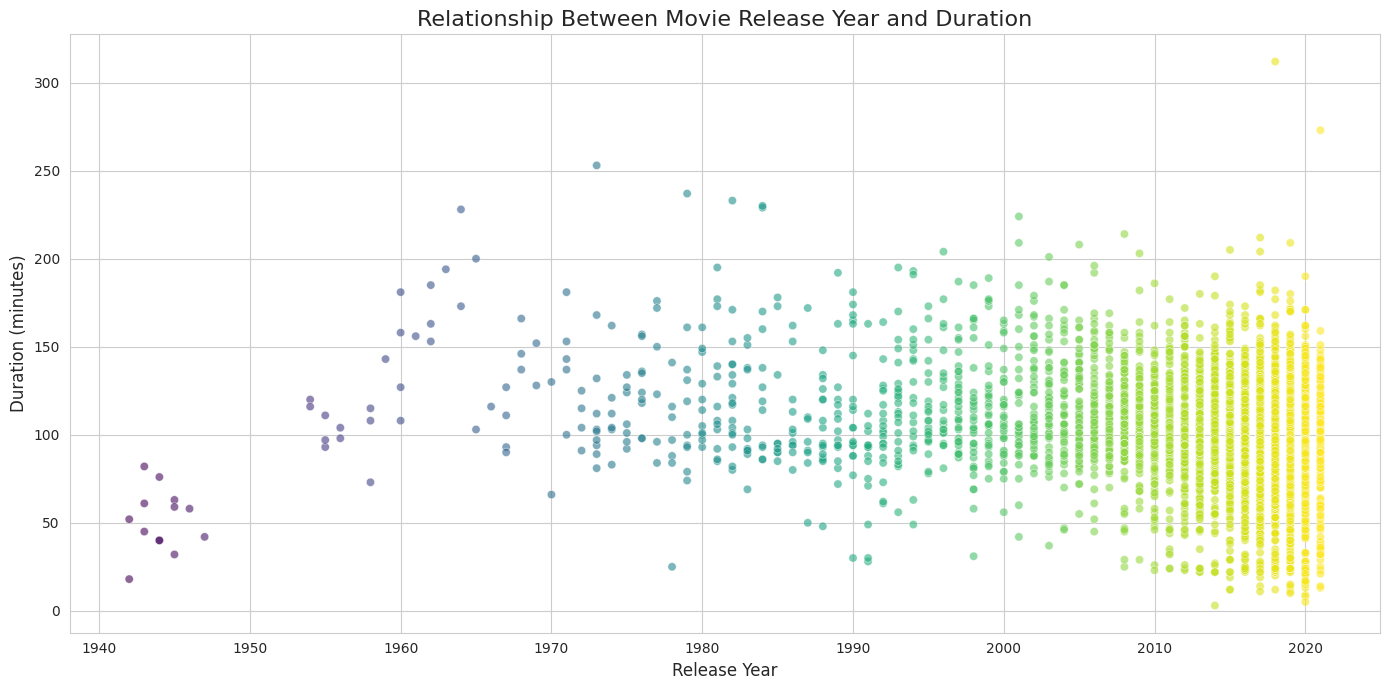

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only movies
movies_only_df = df[df['type'] == 'movie'].copy()

# Drop rows where 'duration_min' is NaN, as these are not movies or had unextractable duration
movies_only_df.dropna(subset=['duration_min'], inplace=True)

# Ensure 'release_year' is integer type for plotting
movies_only_df['release_year'] = movies_only_df['release_year'].astype(int)
movies_only_df['duration_min'] = movies_only_df['duration_min'].astype(int)

print("First 5 rows of movies_only_df with release_year and duration_min:")
print(movies_only_df[['release_year', 'duration_min']].head())

# Visualize the relationship between release year and duration for movies
plt.figure(figsize=(14, 7))
sns.scatterplot(x='release_year', y='duration_min', data=movies_only_df, alpha=0.6, hue='release_year', palette='viridis', legend=False)
plt.title('Relationship Between Movie Release Year and Duration', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous steps successfully analyzed content type distribution, yearly additions, country distribution, content ratings, and the relationship between movie release year and duration. The next step, as per the overall task, is to generate a correlation heatmap for relevant numerical features. I will create a correlation matrix for `release_year` and `duration_min` from the `movies_only_df` and then visualize it using a heatmap.



Correlation Matrix for Movie Release Year and Duration:
              release_year  duration_min
release_year      1.000000     -0.206285
duration_min     -0.206285      1.000000


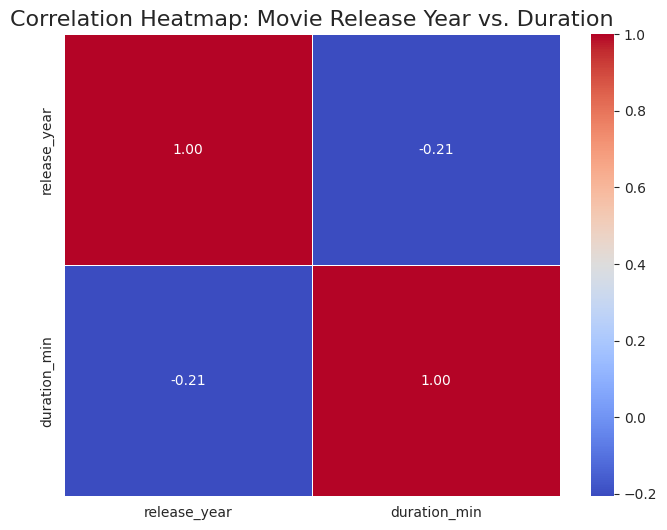

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for relevant numerical features in movies_only_df
# The relevant numerical features are 'release_year' and 'duration_min'
correlation_matrix_movies = movies_only_df[['release_year', 'duration_min']].corr()

print("Correlation Matrix for Movie Release Year and Duration:")
print(correlation_matrix_movies)

# Generate a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_movies, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Movie Release Year vs. Duration', fontsize=16)
plt.show()

## Summary of Findings and Recommendation

### Summary of Findings:

1.  **Content Type Distribution**: Approximately 70% of Netflix's content consists of movies, while TV shows make up the remaining 30%. This indicates a strong focus on movies.
2.  **Yearly Content Additions**: There has been a significant surge in content additions, particularly between 2016 and 2019, with a slight decrease in 2020 and 2021. This suggests a period of aggressive content expansion followed by a potential stabilization or shift in strategy.
3.  **Top Countries by Content Count**: The United States overwhelmingly leads in content production, followed by India and the United Kingdom. This highlights the primary content markets for Netflix.
4.  **Content Ratings**: The majority of content on Netflix is rated 'TV-MA' and 'TV-14', indicating a predominant focus on mature and young adult audiences.
5.  **Movie Release Year vs. Duration**: There is a weak negative correlation (-0.21) between movie release year and duration. This suggests that newer movies tend to be slightly shorter, though the relationship is not very strong.

### Actionable Recommendation for Netflix's Content Strategy:

**Diversify Content Production and Audience Targeting for TV Shows:**

While movies dominate the content library, there's an opportunity to grow the TV show segment. Given the high demand for TV shows and the significant engagement they often generate (e.g., binge-watching), Netflix should consider increasing its investment in TV show production.

Specifically:

*   **Geographic Expansion for TV Shows**: Expand TV show production efforts in countries like India and the UK, which are already significant content contributors. This could involve more localized content or co-productions to cater to diverse global audiences and potentially uncover new talent pools.
*   **Targeted TV Show Ratings**: While 'TV-MA' and 'TV-14' are popular, explore expanding TV show content across a broader range of ratings (e.g., 'PG', 'TV-G') to capture younger audiences and families, especially if this segment is underserved in their current TV show library. This could broaden the subscriber base and increase household engagement.
*   **Monitor Movie Duration Trends**: Continue monitoring movie duration trends. If the slight negative correlation strengthens, consider producing more shorter-form movies to cater to changing viewing habits, or strategically longer films for premium events to maximize viewer engagement.

## Summary of Findings and Recommendation

### Summary of Findings:

1.  **Content Type Distribution**: Approximately 70% of Netflix's content consists of movies, while TV shows make up the remaining 30%. This indicates a strong focus on movies.
2.  **Yearly Content Additions**: There has been a significant surge in content additions, particularly between 2016 and 2019, with a slight decrease in 2020 and 2021. This suggests a period of aggressive content expansion followed by a potential stabilization or shift in strategy.
3.  **Top Countries by Content Count**: The United States overwhelmingly leads in content production, followed by India and the United Kingdom. This highlights the primary content markets for Netflix.
4.  **Content Ratings**: The majority of content on Netflix is rated 'TV-MA' and 'TV-14', indicating a predominant focus on mature and young adult audiences.
5.  **Movie Release Year vs. Duration**: There is a weak negative correlation (-0.21) between movie release year and duration. This suggests that newer movies tend to be slightly shorter, though the relationship is not very strong.

### Actionable Recommendation for Netflix's Content Strategy:

**Diversify Content Production and Audience Targeting for TV Shows:**

While movies dominate the content library, there's an opportunity to grow the TV show segment. Given the high demand for TV shows and the significant engagement they often generate (e.g., binge-watching), Netflix should consider increasing its investment in TV show production.

Specifically:

*   **Geographic Expansion for TV Shows**: Expand TV show production efforts in countries like India and the UK, which are already significant content contributors. This could involve more localized content or co-productions to cater to diverse global audiences and potentially uncover new talent pools.
*   **Targeted TV Show Ratings**: While 'TV-MA' and 'TV-14' are popular, explore expanding TV show content across a broader range of ratings (e.g., 'PG', 'TV-G') to capture younger audiences and families, especially if this segment is underserved in their current TV show library. This could broaden the subscriber base and increase household engagement.
*   **Monitor Movie Duration Trends**: Continue monitoring movie duration trends. If the slight negative correlation strengthens, consider producing more shorter-form movies to cater to changing viewing habits, or strategically longer films for premium events to maximize viewer engagement.

## Analyze Content Types and Release Years

### Subtask:
Analyze the distribution of content types (Movies vs. TV Shows) and calculate the average release year for Movies and TV Shows separately to understand their historical trends.


**Reasoning**:
The previous steps covered data cleaning and initial analysis. Now, I will calculate the average release year for both movies and TV shows to understand their historical trends, as specified in the subtask.



In [38]:
print("## Analyze Content Types and Release Years\n")

# 1. Calculate the average 'release_year' for content where 'type' is 'movie'.
avg_release_year_movies = df[df['type'] == 'movie']['release_year'].mean()

# 2. Calculate the average 'release_year' for content where 'type' is 'tv show'.
avg_release_year_tvshows = df[df['type'] == 'tv show']['release_year'].mean()

# 3. Print the average release year for movies and TV shows.
print(f"Average Release Year for Movies: {avg_release_year_movies:.2f}")
print(f"Average Release Year for TV Shows: {avg_release_year_tvshows:.2f}")

## Analyze Content Types and Release Years

Average Release Year for Movies: 2013.12
Average Release Year for TV Shows: 2016.63


## Explore Yearly Title Additions

### Subtask:
Analyze the trend in the number of titles added to Netflix each year.


### Analysis of Yearly Title Additions Trend

The `yearly_content_additions` series shows a clear trend in Netflix's content additions over time:

*   **Early Years (2008-2014)**: Content additions were very low, with only a handful of titles added each year, indicating the nascent stage of Netflix's original content strategy or its streaming service in general.
*   **Gradual Growth (2015-2016)**: There was a noticeable increase in additions, particularly in 2016 (427 titles), suggesting the beginning of a more aggressive content acquisition/production phase.
*   **Explosive Growth (2017-2019)**: This period saw a massive surge in content, peaking in 2019 with over 2000 titles added. This was likely a time of significant investment by Netflix to rapidly expand its library and fend off rising competition.
*   **Stabilization/Slight Decline (2020-2021)**: After the peak in 2019, the number of additions in 2020 and 2021 showed a slight decrease, albeit still at very high levels (1879 and 1498 titles, respectively). This could indicate a shift towards quality over sheer quantity, market saturation, or impacts from global events affecting production schedules.

## Analyze Rating Categories and Country Distribution

### Subtask:
Identify and report the most common rating category in the dataset. Calculate the distribution of content by country and display the content count for the top 5 countries.


**Reasoning**:
The subtask requires printing the most common rating and the top 5 countries by content count. These values are already available in `rating_distribution` and `top_countries` respectively.



In [39]:
print("\nMost Common Content Rating:")
print(rating_distribution.index[0])

print("\nTop 5 Countries by Content Count:")
print(top_countries.head(5))


Most Common Content Rating:
tv-ma

Top 5 Countries by Content Count:
           country  count
0    United States   3680
3            India   1046
6   United Kingdom    803
16          Canada    445
13          France    393


## Final Task

### Subtask:
Provide a comprehensive summary of the Netflix content analysis, reiterating the most significant trends, distributions, and relationships identified. Conclude with the actionable recommendation for Netflix's content strategy, based on the insights gained from the dataset.


## Summary:

### Q&A
*   **What are the most significant trends, distributions, and relationships identified in the Netflix content analysis?**
    *   **Content Type Distribution**: Approximately 69.7% of Netflix's content consists of movies, with TV shows making up the remaining 30.3%.
    *   **Yearly Content Additions**: There was an explosive growth in content additions between 2017 and 2019, peaking in 2019 with over 2000 titles added. This was followed by a slight decrease in 2020 and 2021.
    *   **Top Content Producing Countries**: The United States leads overwhelmingly with 3680 titles, followed by India (1046 titles) and the United Kingdom (803 titles).
    *   **Predominant Content Ratings**: The majority of content is rated 'TV-MA' (3209 titles) and 'TV-14' (2157 titles), indicating a focus on mature and young adult audiences.
    *   **Movie Release Year vs. Duration**: A weak negative correlation of -0.21 exists between movie release year and duration, suggesting newer movies tend to be slightly shorter.
    *   **Average Release Year**: The average release year for movies is 2013.12, while for TV shows it is 2016.63, indicating that TV shows on Netflix are, on average, more recently produced than movies.

*   **What is the actionable recommendation for Netflix's content strategy based on the insights gained from the dataset?**
    The recommendation is to **Diversify Content Production and Audience Targeting for TV Shows**. This involves increasing investment in TV show production, expanding geographic efforts for TV shows in countries like India and the UK, and exploring a broader range of TV show ratings (e.g., 'PG', 'TV-G') to capture younger and family audiences. Netflix should also monitor movie duration trends and consider producing more shorter-form movies if the negative correlation strengthens.

### Data Analysis Key Findings
*   The dataset contains 8807 rows and 12 columns.
*   Initial inspection revealed significant missing values in `director` (2634), `cast` (825), and `country` (831) which were subsequently filled with 'Unknown'.
*   Missing `rating` values were filled with the mode, and rows with missing `date_added` and `duration` were dropped, ensuring a clean dataset for analysis.
*   The `date_added` column was successfully converted to datetime objects, and `duration` was separated into `duration_min` for movies and `duration_seasons` for TV shows.
*   Movies constitute approximately 69.7% of Netflix's content library, while TV shows make up 30.3%.
*   Content additions to Netflix saw a peak in 2019 with over 2000 titles, following explosive growth from 2017, and then slightly decreased in 2020 and 2021.
*   The United States is the largest contributor to Netflix's content with 3680 titles, followed by India with 1046 titles and the United Kingdom with 803 titles.
*   The most prevalent content ratings are 'TV-MA' and 'TV-14', indicating a strong focus on mature and young adult audiences.
*   There is a weak negative correlation ($r = -0.21$) between a movie's release year and its duration, suggesting a slight trend towards shorter movies over time.
*   The average release year for movies on Netflix is 2013.12, while for TV shows it is 2016.63, indicating a more recent average production date for TV shows.

### Insights or Next Steps
*   **Strategic Investment in TV Shows**: Given the high demand and engagement potential of TV shows, Netflix should increase its investment in TV show production, particularly expanding localized content in key markets like India and the UK, and diversifying rating categories to attract broader family audiences.
*   **Monitor Content Trends**: Continuously monitor content addition trends and the subtle shift towards shorter movie durations. This data can inform future production strategies, balancing quality versus quantity and adapting to evolving viewer preferences.
